This time, you need create a multilayer NN, which can learn a more difficult Pattern. After this task you should feel compfortable creating simple NNs with tensorflow and training them.

# Import Libraries

In [8]:
import torch
import torch.nn.functional as F
import torch.nn            as nn
import torch.optim         as optim

import numpy as np
import math
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

%matplotlib inline

# Create Data

In the Toy example, we have a two-dimensional data set: $(x_1,x_2) \in [-1,1] \times [-1,1]$. We want to train the network to output 1, if $x_1 + x_2 >= 1$. Otherwise, the network should output 0. Therefore, we are going to create a dataset with the corresponding labels. We furthermore divide the data into a training set and a test set.

In the following code, you do not need to do anything. However, you should understand what is going on.

In [9]:
# Define total number of samples
tot_number_samples = 10000

# Create a dataset randomly and calculate the necessary labels
X = np.random.uniform(-1,1,(tot_number_samples,2))
level = X[:,0]*X[:,0] + X[:,1]*X[:,1] + np.random.randn(tot_number_samples)*0.05
y = (level<0.7)*1.*(level>0.3)

# Divide the dataset into a train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25) #25 % of data is in test set

In [10]:
# Move data to device
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test  = torch.from_numpy(X_test).float()
y_test  = torch.from_numpy(y_test).float()

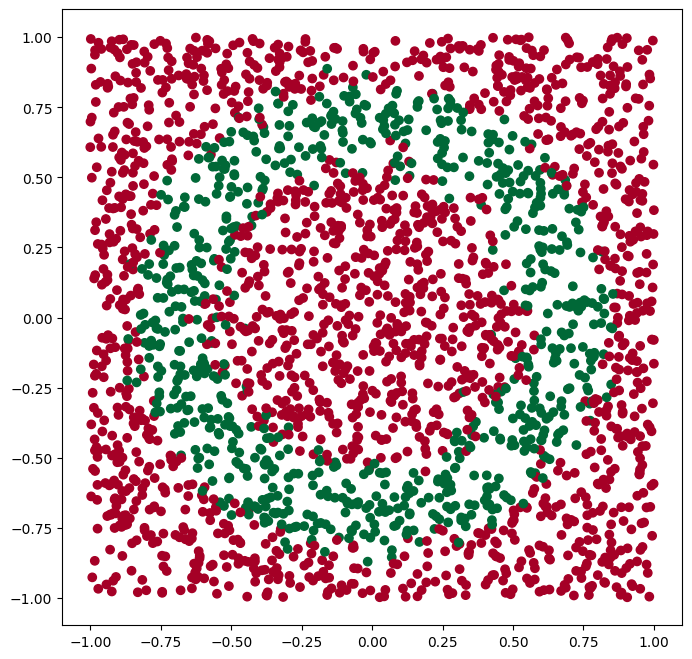

In [11]:
# Plot the test data in a graph for visualization
plt.figure(figsize=(8,8))

plt.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap="RdYlGn")

plt.show()

# Build the Network

Similar to last time, create a NN with input and output vectors. But this time there are also hidden layers. You could also come up with a way to process your input data in the first layer to optimize it for the given task.

If you have troubles with finding a network architecture that actually works, chances are you are just using too many nodes and too many layers. If the network is too large to be trained on the computer, it is too large for this task. Do not forget the non-linearities.

If you still have troubles, think about what activations functions make sense for each of your layers. Where is a sigmoid helpful, where could you try a relu?

In [24]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        
        # ToDo: Define your network layers here
        self.hidden1 = nn.Linear(2,64)
        self.hidden2 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
        
    def forward(self,x):
        # This functions tells torch, how the layers are actually connected. More complex networks will have more complex code here
        
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))
        x = self.output(x)
        x = torch.sigmoid(x)
        
        return x.squeeze(-1)
        
    
    def predict(self,x):
        # Make a prediction (0 or 1), to which class the data belongs to
        
        out = self.forward(x)
        out = (out>0.5).float()
        return out

In [25]:
ann       = ANN()                                # Make an object of your ANN class
optimizer = optim.Adam(params=ann.parameters())  # Define the optimizer

# Train the Network

This part should be pretty much identical to the last exercise

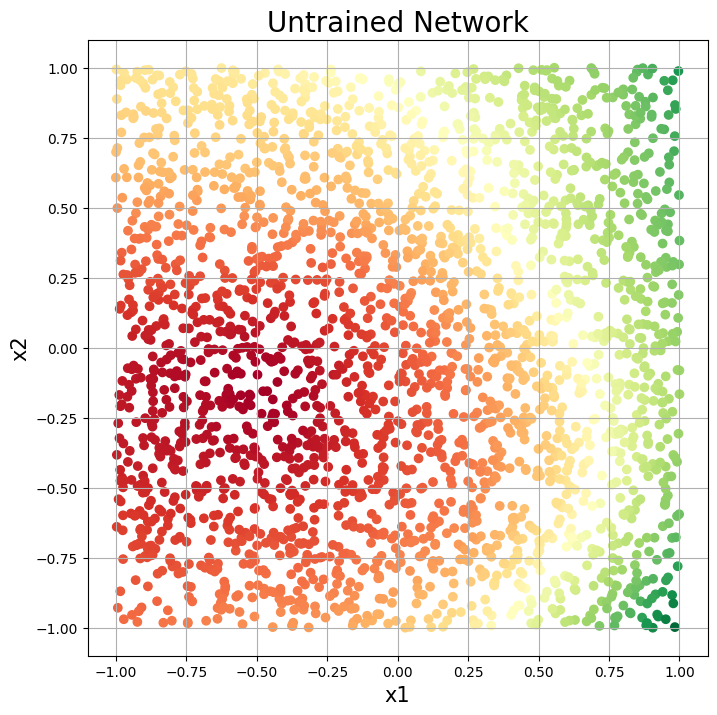

In [26]:
# Make a prediction by the untrained network and plot it
ann.eval()
y_pred = ann.forward(X_test).detach().numpy()

# Plot the raw data
plt.figure(figsize=(8,8))
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred,cmap="RdYlGn")
plt.grid(True)
plt.xlabel('x1',fontsize=15)
plt.ylabel('x2',fontsize=15)
plt.title('Untrained Network',fontsize=20)
plt.show()

In [27]:
n_epochs                = 250
batch_size              = 128

n_iterations_per_epoch  = y_train.shape[0] // batch_size
n_iterations_validation = y_test.shape[0] // batch_size
best_loss_val           = np.inf

for epoch in range(n_epochs):
    # Train your network
    ann.train()
   
    for iteration in range(n_iterations_per_epoch):
        X_batch = X_train[iteration*batch_size:(iteration+1)*batch_size,:]
        y_batch = y_train[iteration*batch_size:(iteration+1)*batch_size]
        
        optimizer.zero_grad()                # Reset the gradients
        
        y_pred  = ann.forward(X_batch)       # make a prediciton
        loss    = F.mse_loss(y_batch,y_pred) # Get the actual loss
        loss.backward()                      # Calculate the gradients.
        
        optimizer.step()                     # Apply the gradients
            
    # Evaluation
    ann.eval()
   
    y_pred   = ann.predict(X_test)
    loss_val = F.mse_loss(y_test,ann.forward(X_test)).detach().numpy()
    
    accuracy = (torch.mean((torch.abs(y_pred-y_test)<1e-4).float())).detach().numpy()
    
    print("\rEpoch: {}  Val accuracy: {:.4f}%  Loss: {:.6f}{}".format(
        epoch+1, accuracy * 100, loss_val,
        " (improved)" if loss_val < best_loss_val else ""))

    # Update best val loss, if improved
    if loss_val < best_loss_val:
        best_loss_val = loss_val

Epoch: 1  Val accuracy: 69.4800%  Loss: 0.207383 (improved)
Epoch: 2  Val accuracy: 69.4800%  Loss: 0.197335 (improved)
Epoch: 3  Val accuracy: 69.4800%  Loss: 0.187070 (improved)
Epoch: 4  Val accuracy: 71.8000%  Loss: 0.175760 (improved)
Epoch: 5  Val accuracy: 75.5600%  Loss: 0.163478 (improved)
Epoch: 6  Val accuracy: 77.4800%  Loss: 0.148621 (improved)
Epoch: 7  Val accuracy: 82.4800%  Loss: 0.131868 (improved)
Epoch: 8  Val accuracy: 88.1600%  Loss: 0.114980 (improved)
Epoch: 9  Val accuracy: 91.0400%  Loss: 0.100320 (improved)
Epoch: 10  Val accuracy: 91.8800%  Loss: 0.089311 (improved)
Epoch: 11  Val accuracy: 92.3600%  Loss: 0.081198 (improved)
Epoch: 12  Val accuracy: 92.4800%  Loss: 0.075176 (improved)
Epoch: 13  Val accuracy: 92.6000%  Loss: 0.070652 (improved)
Epoch: 14  Val accuracy: 92.6000%  Loss: 0.067189 (improved)
Epoch: 15  Val accuracy: 92.6400%  Loss: 0.064483 (improved)
Epoch: 16  Val accuracy: 92.6400%  Loss: 0.062325 (improved)
Epoch: 17  Val accuracy: 92.8400%

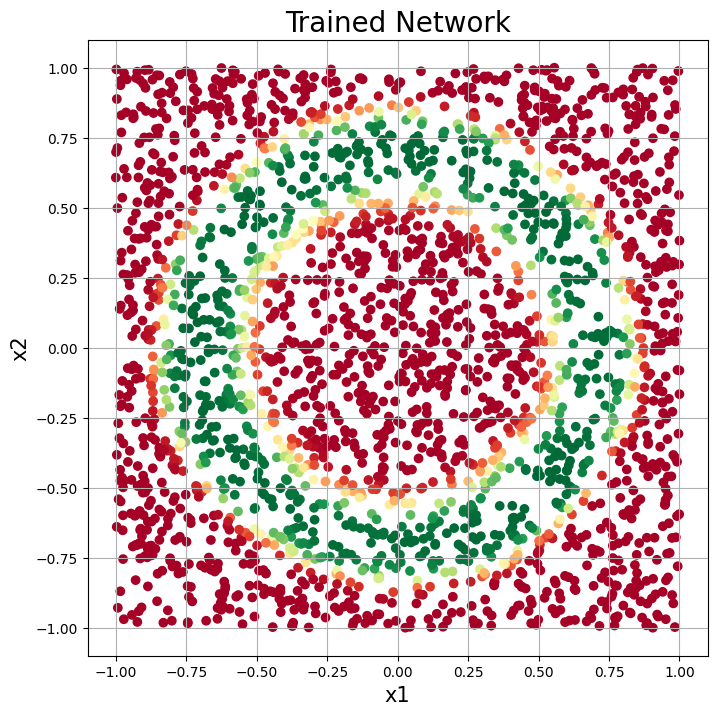

In [28]:
# Make a prediction of the trained network and plot it
 # Make a prediction of the trained network and plot it
ann.eval()
y_pred = ann.forward(X_test).cpu().detach().numpy()

# Plot the raw data
plt.figure(figsize=(8,8))
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred,cmap="RdYlGn")
plt.grid(True)
plt.xlabel('x1',fontsize=15)
plt.ylabel('x2',fontsize=15)
plt.title('Trained Network',fontsize=20)
plt.show()

Do you manage to detect both the inside and the outside of the annulus (German: Kreisring)?

In [29]:
# Yes, 250 epochs seem to be enough, there is no meaningful improvement after that.
# Accuracy scales now with node size, but scaling from 32 to 64 also didnt yield much improvement. 
# All in all, the boundaries are nicely seen :)